# **Проект "Нейросеть для предсказания калорийности блюд"**

## **1. Введение**

**Описание проекта:** заказчик обратился с запросом — создать и обучить нейросеть, которая будет предсказывать калорийность блюд по фотографии блюда и по его текстовому описанию ингредиентного состава. Требование - MAE < 50 на тестовой выборке.

**Цель:** создать и обучить DL-модель, способную оценить калорийность блюда

**План работы:**
1) загрузка и предобработка данных (анализ данных, устранение пропусков/дубликатов/аномалий + объяснение стратегии решения задачи) 
2) обучение и валидация DL-модели
3) оценка качества (метрика MAE) и выбор наилучшей DL-модели
4) формулирование итогов работы

**Имеющиеся данные:** датасеты с характеристиками блюд (масса, калории, ингредиенты, ID) и фотографиями, находящийся по адресу https://disk.yandex.ru/d/kz9g5msVqtahiw

In [1]:
# ============================================
# 0. ИМПОРТ БИБЛИОТЕК
# ============================================

import sys
import os
from pathlib import Path

import zipfile
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from collections import Counter
import random

import shutil
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models
from torchvision import transforms


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


from tqdm import tqdm
import time
from datetime import datetime

import json
import joblib

# Добавляем путь к scripts
sys.path.append(os.path.join(os.getcwd(), 'scripts'))

import warnings
warnings.filterwarnings('ignore')

# импортируем функции и классы из папки scripts
from load_save_datasets import get_direct_yandex_link, datasets_load_save
from show_images_examples import show_sample_images
from create_ingredient_vector import get_ingredient_vector
from create_data_loaders import get_data_loaders
from create_model import DishCalorieModel
from dish_dataset import DishDataset
from seed import set_seed
from train_validation_functions import train_one_epoch, validate, train
from config import save_config, load_config
from recreate_ingredients_list import extract_numeric_id, id_to_ingredient_name, filter_and_convert_ingredients

**Используем gpu для ускорения вычислений:**

In [2]:
# ============================================
# 1. ВЫБОР УСТРОЙСТВА (GPU ИЛИ CPU) ДЛЯ ВЫЧИСЛЕНИЙ
# ============================================

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Используется устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 17.10 GB


In [3]:
# ============================================
# 2. КОНСТАНТЫ ДЛЯ СКАЧИВАНИЯ
# ============================================

YANDEX_DISK_URL = "https://disk.yandex.ru/d/kz9g5msVqtahiw"
DATASETS_DIR = "data"
ARCHIVE_NAME = "dataset.zip"

## **2. Анализ и предобработка данных**

### **2.1 Загрузка и анализ данных**

Скачиваем и распаковываем данные с Яндекс.диска:

In [4]:
# ============================================
# 3. СКАЧИВАЕМ И РАСПАКОВЫВАЕМ ДАННЫЕ С ЯНДЕКС.ДИСКА
# ============================================

datasets_load_save(YANDEX_DISK_URL)

# Загружаем CSV файлы из папки datasets
# Фотографии не сохраняем в виде переменных (для простоты)
dishes_df = pd.read_csv(os.path.join(DATASETS_DIR, 'dish.csv'))
ingredients_df = pd.read_csv(os.path.join(DATASETS_DIR, 'ingredients.csv'))

print('Таблицы из папки datasets загружены')

Получение прямой ссылки для скачивания...
Прямая ссылка получена!
Начинается скачивание архива...


Скачивание: 100%|██████████| 1.43G/1.43G [02:12<00:00, 10.8MB/s]


✅ Скачивание завершено!
Распаковка архива...
✅ Папка 'data' перемещена в текущую директорию
✅ Распаковка завершена!
Таблицы из папки datasets загружены


Визуализируем загруженные данные и проанализируем общую статистику (распределения):


СТАТИСТИКА ДАННЫХ (describe())

=== Статистика калорийности ===
count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64

=== Статистика массы блюд ===
count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64

ОБРАБОТКА ИНГРЕДИЕНТОВ

Статистика по ингредиентам:
 - Всего уникальных ингредиентов: 555
 - Среднее количество ингредиентов на блюдо: 7.31
  - Медиана количества ингредиентов: 4
  - Максимум ингредиентов в одном блюде: 34

ВИЗУАЛИЗАЦИЯ ДАННЫХ


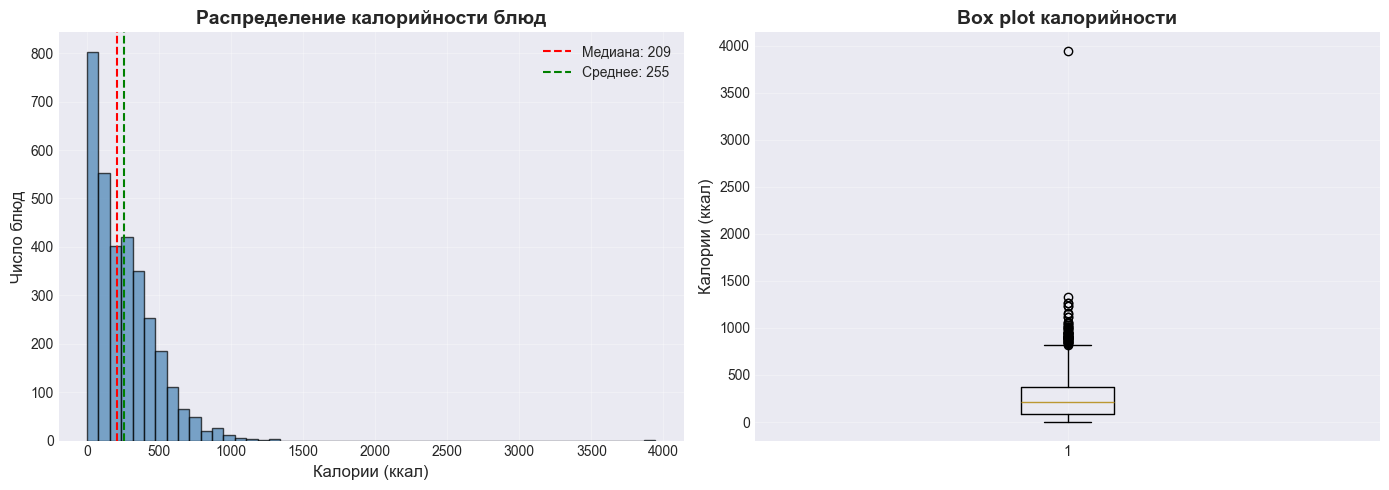

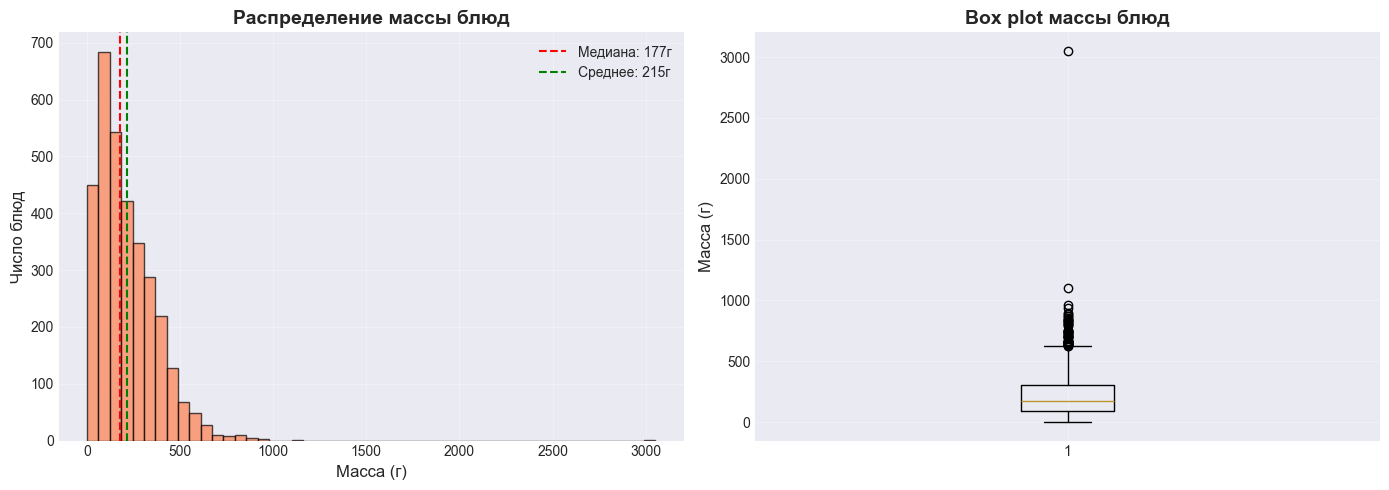

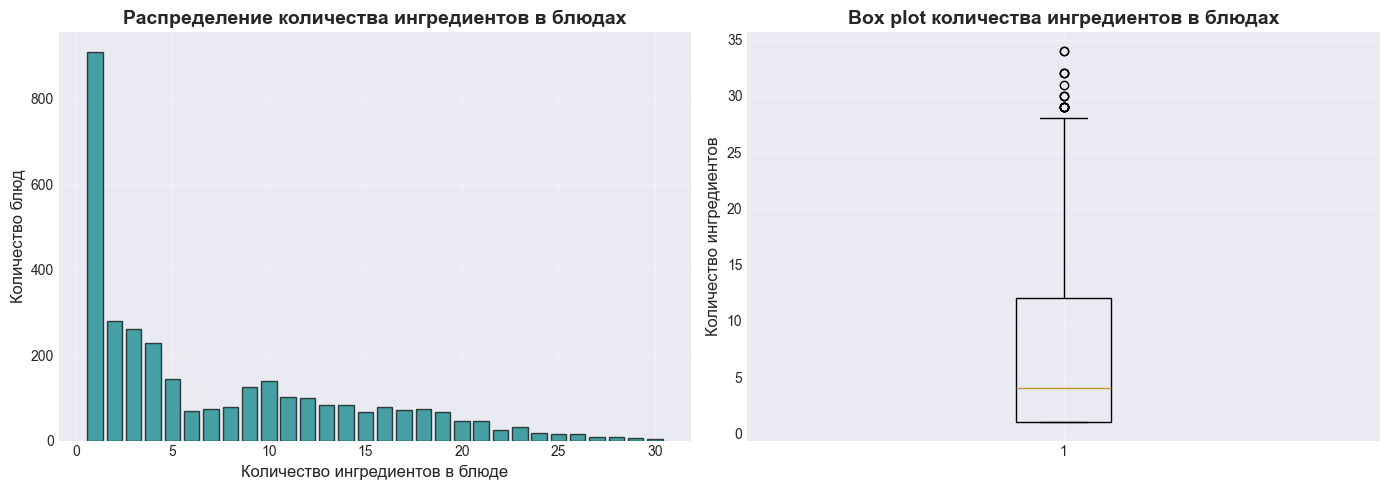

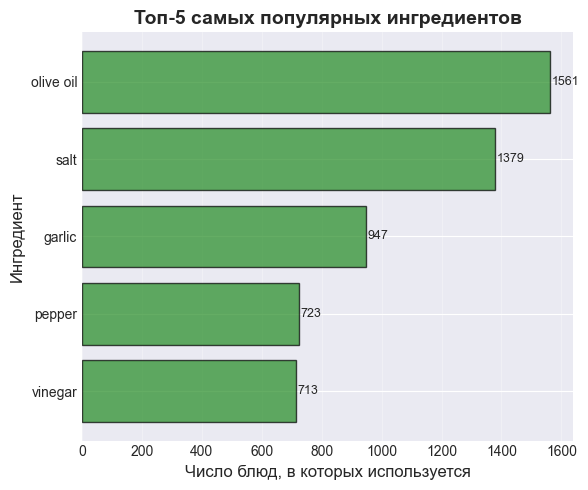


СТАТИСТИКА ПО ИНГРЕДИЕНТАМ
Топ-5 самых частых ингредиентов:
  1. olive oil: встречается в 1561 блюдах (47.9%)
  2. salt: встречается в 1379 блюдах (42.3%)
  3. garlic: встречается в 947 блюдах (29.0%)
  4. pepper: встречается в 723 блюдах (22.2%)
  5. vinegar: встречается в 713 блюдах (21.9%)

Топ-5 самых редких ингредиентов:
  1. toast: встречается в 1 блюдах (0.0%)
  2. balsamic vinegar: встречается в 1 блюдах (0.0%)
  3. wheat bread: встречается в 1 блюдах (0.0%)
  4. banana with peel: встречается в 1 блюдах (0.0%)
  5. orange with peel: встречается в 1 блюдах (0.0%)


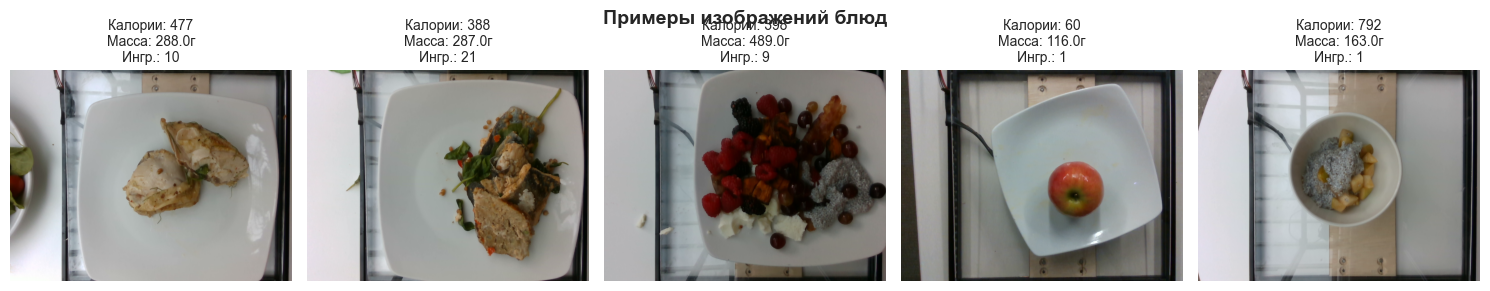


ИТОГОВАЯ СТАТИСТИКА ПО ДАННЫМ
Размер датасета: 3262 записей
Признаки: dish_id, total_calories, total_mass, ingredients, split, ingredients_list (вспомогательный-'служебный'), num_ingredients (новый), ingredient_vector (новый)
Целевая переменная: total_calories (калорийность)
Диапазон калорий: [0, 3943]
Диапазон массы: [1, 3051]
Уникальных ингредиентов: 555


In [5]:
# ============================================
# 4. ПРОСМОТР И АНАЛИЗ ДАННЫХ
# ============================================
print("\n" + "="*60)
print("СТАТИСТИКА ДАННЫХ (describe())")
print("="*60)

print("\n=== Статистика калорийности ===")
print(dishes_df['total_calories'].describe())

print("\n=== Статистика массы блюд ===")
print(dishes_df['total_mass'].describe())

# Парсинг ингредиентов
print("\n" + "="*60)
print("ОБРАБОТКА ИНГРЕДИЕНТОВ")
print("="*60)

# Создание словаря ингредиентов
ingr_dict = dict(zip(ingredients_df['id'], ingredients_df['ingr']))

# Парсинг ингредиентов для каждого блюда
dishes_df['ingredients_list'] = dishes_df['ingredients'].apply(
    lambda x: x.split(';') if pd.notna(x) else []
)

# Создание словаря для one-hot encoding (будет использован в дальнейшем при создании векторов ингредиентов, то есть dishes_df['ingredient_vector'])
all_ingredients = sorted(ingredients_df['id'].unique())
ingr_to_idx = {ingr: i for i, ingr in enumerate(all_ingredients)}
num_ingredients = len(all_ingredients)

# Количество ингредиентов
dishes_df['num_ingredients'] = dishes_df['ingredients_list'].apply(len)

print(f"\nСтатистика по ингредиентам:")
print(f" - Всего уникальных ингредиентов: {len(ingr_dict)}")
print(f" - Среднее количество ингредиентов на блюдо: {dishes_df['num_ingredients'].mean():.2f}")
print(f"  - Медиана количества ингредиентов: {dishes_df['num_ingredients'].median():.0f}")
print(f"  - Максимум ингредиентов в одном блюде: {dishes_df['num_ingredients'].max()}")


# Визуализации
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ДАННЫХ")
print("="*60)

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Распределение калорийности + Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(dishes_df['total_calories'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Калории (ккал)', fontsize=12)
axes[0].set_ylabel('Число блюд', fontsize=12)
axes[0].set_title('Распределение калорийности блюд', fontsize=14, fontweight='bold')
axes[0].axvline(x=dishes_df['total_calories'].median(), color='red', linestyle='--', 
                label=f'Медиана: {dishes_df["total_calories"].median():.0f}')
axes[0].axvline(x=dishes_df['total_calories'].mean(), color='green', linestyle='--', 
                label=f'Среднее: {dishes_df["total_calories"].mean():.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(dishes_df['total_calories'], vert=True)
axes[1].set_ylabel('Калории (ккал)', fontsize=12)
axes[1].set_title('Box plot калорийности', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Распределение массы блюд + Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(dishes_df['total_mass'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Масса (г)', fontsize=12)
axes[0].set_ylabel('Число блюд', fontsize=12)
axes[0].set_title('Распределение массы блюд', fontsize=14, fontweight='bold')
axes[0].axvline(x=dishes_df['total_mass'].median(), color='red', linestyle='--', 
                label=f'Медиана: {dishes_df["total_mass"].median():.0f}г')
axes[0].axvline(x=dishes_df['total_mass'].mean(), color='green', linestyle='--', 
                label=f'Среднее: {dishes_df["total_mass"].mean():.0f}г')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(dishes_df['total_mass'], vert=True)
axes[1].set_ylabel('Масса (г)', fontsize=12)
axes[1].set_title('Box plot массы блюд', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Распределение частоты встречаемости ингредиентов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Частота встречаемости ингредиентов (по id)
ingredient_freq = dishes_df['num_ingredients'].value_counts().sort_index()

axes[0].bar(ingredient_freq.index[:30], ingredient_freq.values[:30], 
            edgecolor='black', alpha=0.7, color='teal')
axes[0].set_xlabel('Количество ингредиентов в блюде', fontsize=12)
axes[0].set_ylabel('Количество блюд', fontsize=12)
axes[0].set_title('Распределение количества ингредиентов в блюдах', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)


# Box plot количества ингредиентов
axes[1].boxplot(dishes_df['num_ingredients'], vert=True)
axes[1].set_ylabel('Количество ингредиентов', fontsize=12)
axes[1].set_title('Box plot количества ингредиентов в блюдах', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Топ-5 самых популярных ингредиентов

# Собираем все ингредиенты
all_ingredients_list = []
for ingredients in dishes_df['ingredients_list']:
    all_ingredients_list.extend(ingredients)

ingredient_counts = Counter(all_ingredients_list)
top_ingredients = ingredient_counts.most_common(5)

# Преобразуем ID в названия
top_ingredients_names = []
for ingr_id_str, count in top_ingredients:
    # Извлекаем числовой ID из строки вида 'ingr_0000000161'
    # Удаляем префикс 'ingr_' и ведущие нули
    if ingr_id_str.startswith('ingr_'):
        numeric_id = int(ingr_id_str.replace('ingr_', '').lstrip('0') or '0')
    else:
        numeric_id = int(ingr_id_str)
    name = ingr_dict.get(numeric_id, f"Unknown ({ingr_id_str})")
    top_ingredients_names.append((name, count))

plt.figure(figsize=(6, 5))
names, counts = zip(*top_ingredients_names)
y_pos = range(len(names))

plt.barh(y_pos, counts, edgecolor='black', alpha=0.7, color='forestgreen')
plt.yticks(y_pos, names, fontsize=10)
plt.xlabel('Число блюд, в которых используется', fontsize=12)
plt.ylabel('Ингредиент', fontsize=12)
plt.title('Топ-5 самых популярных ингредиентов', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# Добавляем значения на бары
for i, (name, count) in enumerate(top_ingredients_names):
    plt.text(count + 5, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Дополнительная статистика по ингредиентам
print("\n" + "="*60)
print("СТАТИСТИКА ПО ИНГРЕДИЕНТАМ")
print("="*60)

# Выводим топ-5 самых частых
print(f"Топ-5 самых частых ингредиентов:")
for i, (name, count) in enumerate(top_ingredients_names[:5], 1):
    print(f"  {i}. {name}: встречается в {count} блюдах ({count/len(dishes_df)*100:.1f}%)")

# Топ-5 самых редких ингредиентов (исправленная версия)
rare_ingredients = ingredient_counts.most_common()[:-6:-1]

print(f"\nТоп-5 самых редких ингредиентов:")
for i, (ingr_id_str, count) in enumerate(rare_ingredients, 1):
    if ingr_id_str.startswith('ingr_'):
        numeric_id = int(ingr_id_str.replace('ingr_', '').lstrip('0') or '0')
    else:
        numeric_id = int(ingr_id_str)
    
    # Ищем в ingr_dict (который создан из очищенного ingredients_df)
    name = ingr_dict.get(numeric_id)
    
    # Если не нашли, пробуем поискать в исходных данных или выводим понятное имя
    if name is None:
        name = f"Ингредиент_{numeric_id}"
    
    print(f"  {i}. {name}: встречается в {count} блюдах ({count/len(dishes_df)*100:.1f}%)")

# Визуализация примеров изображений
images_path = os.path.join(DATASETS_DIR, 'images')
if os.path.exists(images_path):
    show_sample_images(dishes_df, images_path)
else:
    print(f"\n⚠️ Папка с изображениями не найдена: {images_path}")

# Итоговая статистика
print("\n" + "="*60)
print("ИТОГОВАЯ СТАТИСТИКА ПО ДАННЫМ")
print("="*60)
print(f"Размер датасета: {len(dishes_df)} записей")
print(f"Признаки: dish_id, total_calories, total_mass, ingredients, split, ingredients_list (вспомогательный-'служебный'), num_ingredients (новый), ingredient_vector (новый)")
print(f"Целевая переменная: total_calories (калорийность)")
print(f"Диапазон калорий: [{dishes_df['total_calories'].min():.0f}, {dishes_df['total_calories'].max():.0f}]")
print(f"Диапазон массы: [{dishes_df['total_mass'].min():.0f}, {dishes_df['total_mass'].max():.0f}]")
print(f"Уникальных ингредиентов: {len(sorted(ingredients_df['id'].unique()))}")

Исходя из вышеприведённых графиков и фотографий можно сделать **следующие выводы:**

1) большинство блюд имеют калорийность менее 500 ккал (медиана и среднее — 209 и 255 ккал соответственно), при этом распределение несимметрично (смещение к меньшим значениям калорий) + согласно box plot блюда с калорийностью более 800 ккал являются "выбросами" (нетипичными значениями)
2) масса большинства блюд не превышает 500 г + согласно box plot блюда с массой более 600 г являются "выбросами" 
3) значительная часть блюд имеет в своём составе всего один ингредиент, при этом в среднем на одно блюдо приходится  ~ 7 ингредиентов, а число блюд с > 26 инградиентами очень мало (менее 2 %), что также следует из box plot
4) в топ-5 самых популярных игредиентов входят: olive oil (оливковое масло), salt (соль), garlic (чеснок), pepper (перец), vinegar (уксус), что вполне ожидаемо,поскольку эти игредиенты в принципе широко используются в приготовлении многих блюд
5) из топ-5 наиболее редких ингредиентов следует, что некоторые ингредиенты используются лишь в одном блюде - например, banana with peel (банан с кожурой) или balsamic vinegar (бальзамический уксус)

Отметим, что есть единичные блюда с необычно высокими значениями калорийности и массы (около 4000 ккал и 3000 г) — **вероятно** это **ошибка** в исходных данных. По крайней мере для модели такие примеры **не будут полезными.** 

### **2.2 Стратегия решения и аугментации**

Из анализа данных (см. выше раздел 2.1) также следуют **выводы про аугментации фото и общий подход к решению задачи:**

**Во-первых,** фотографий блюд - судя по примерам - сделаны сверху, но при этом сама тарелка и блюдо не имеют строгой ориентации (могут быть по-разному повёрнуты), поэтому **в качестве агументаций** можно использовать **поворот на некоторый угол** (RandomRotation, до 15 градусов) и **отраженение по вертикали** (RandomHorizontalFlip). Кроме того, фото могут быть сделаны при разной степени освещённости, поэтому в качестве аугментации **можно добавить** ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1). 

**Во-вторых**, учитывая большое количество названий уникальных ингредиентов (555), представляется логичным использовать **one-hot представления ингредиентов**, то есть для каждого блюда составить вектор  размерностью N (где N - число уникальных ингредиентов), где на каждой позиции 1 — это присутствие конкретного ингредиента в составе блюда, а 0 — соответственно отсутствие. Число N вместо 555 указано в связи с тем, что мы пока не проверяли дубликаты в списке названий уникальных ингредиентов, поэтому в реальности вектор может быть меньшего размера. 

**В-третьих**, поскольку для предсказания целевого признака (калорийности) используются данные **разных типов** (табличные данные и изображения), то нужно использовать **комбинацию нескольких моделей.** Для работы **с изображениями** будем использовать предобученную **модель ResNet-50** (с весами ImageNet), где заменим слой fc (то есть заменим Linear на Identity, поскольку нам нужно не предсказывать классы, а получить признаки из изображения) и заморозим все слои, кроме layer4, который извлекает специфичные признаки и который нужно обучить заново. **Для  работы с one-hot векторами, с массами и для для конкатенации всех признаков** (предсказания калорий по объединённым данным) будем использовать **свои MLP,** обучая их "с нуля".

**В-четвёртых**, в функции потерь будем использовать MSE, поскольку — в отличие от MAE — гладкая функция (производная определена везде) + сильнее штрафует за большие ошибки (заказчик требует относительно высокой точности — MAE < 50 на тесте). Кроме того, качество модели будем оценивать метрикой MAE (поскольку MAE на тесте должно быть менее < 50). И в качестве некоторой "общей" оценки будем использовать R2 (покажет, насколько сильно лучше модель по сравнению со случайным угадыванием).

Ниже для наглядности представлена **схема архитектуры используемой мультимодальной модели:**

In [6]:
print("""
 ┌──────────────────────┐    ┌─────────────────┐      ┌─────────────────┐
 │     состав блюда     │    │   масса блюда   │      │   фото блюда    │
 │ (dish + ingredients) │    │     (dish)      │      │ (папка images)  │
 └───────────┬──────────┘    └────────┬────────┘      └────────┬────────┘
             │                        │                        │
             ▼                        ▼                        ▼
    ┌─────────────────┐      ┌─────────────────┐      ┌─────────────────┐
    │ one-hot вектор  │      │   нормализация  │      │    ResNet-50    │
    │     (551)       │      │      массы      │      │      (CNN)      │
    └────────┬────────┘      └────────┬────────┘      └────────┬────────┘
             │                        │                        │
             ▼                        ▼                        ▼
    ┌─────────────────┐      ┌─────────────────┐      ┌─────────────────┐
    │  ingredient_fc  │      │     mass_fc     │      │    визуальные   │
    │     (MLP)       │      │      (MLP)      │      │  признаки (2048)│
    └────────┬────────┘      └────────┬────────┘      └────────┬────────┘
             │                        │                        │
             ▼                        ▼                        │
            256                       32                       │
             └────────────────────────┼────────────────────────┘
                                      │
                                      ▼
                             ┌─────────────────┐
                             │   конкатенация  │
                             │    признаков    │  
                             │   (2336 фичей)  │
                             └────────┬────────┘
                                      │
                                      ▼
                             ┌─────────────────┐
                             │   combined_fc   │
                             │      (MLP)      │
                             └────────┬────────┘
                                      │
                                      ▼
                             ┌─────────────────┐
                             │     калории     │
                             └─────────────────┘
""")


 ┌──────────────────────┐    ┌─────────────────┐      ┌─────────────────┐
 │     состав блюда     │    │   масса блюда   │      │   фото блюда    │
 │ (dish + ingredients) │    │     (dish)      │      │ (папка images)  │
 └───────────┬──────────┘    └────────┬────────┘      └────────┬────────┘
             │                        │                        │
             ▼                        ▼                        ▼
    ┌─────────────────┐      ┌─────────────────┐      ┌─────────────────┐
    │ one-hot вектор  │      │   нормализация  │      │    ResNet-50    │
    │     (551)       │      │      массы      │      │      (CNN)      │
    └────────┬────────┘      └────────┬────────┘      └────────┬────────┘
             │                        │                        │
             ▼                        ▼                        ▼
    ┌─────────────────┐      ┌─────────────────┐      ┌─────────────────┐
    │  ingredient_fc  │      │     mass_fc     │      │    визуальные   │

**Более подробно** архитектуру используемой мультимодальной модели можно посмотреть **в файле create_model.py.**

### **2.3 Устранение пропусков, дубликатов и аномалий**

Проверим, есть ли в наших данных (в табличных и в фото) пропуски и дубликаты:

In [7]:
# ============================================
# 5. ПРОВЕРКА НА ПРОПУСКИ, ДУБЛИКАТЫ И СООТВЕТСТВИЕ ID
# ============================================

import hashlib

print(f"\n✅ Статистика:")
print(f"  - Всего блюд: {len(dishes_df)}")
print(f"  - Всего ингредиентов: {len(ingredients_df)}")
print(f"  - Train блюд: {len(dishes_df[dishes_df['split'] == 'train'])}")
print(f"  - Test блюд: {len(dishes_df[dishes_df['split'] == 'test'])}")
print(f"  - Папка с изображениями: {os.path.join(DATASETS_DIR, 'images')}")

# Анализ пропусков (NaN)
print("\n" + "="*60)
print("АНАЛИЗ ПРОПУСКОВ (NaN)")
print("="*60)

nan_counts = dishes_df.isna().sum()
print("\nКоличество пропусков в каждом столбце в dishes_df:")
for col, count in nan_counts.items():
    if count > 0:
        print(f"  {col}: {count} пропусков ({count/len(dishes_df)*100:.2f}%)")
    else:
        print(f"  {col}: {count} пропусков")

# Анализ дубликатов
print("\n" + "="*60)
print("АНАЛИЗ ДУБЛИКАТОВ")
print("="*60)

# Проверка дубликатов dish_id в dishes_df
print("\n🔍 1. Проверка dishes_df на дубликаты dish_id:")
dish_id_counts = dishes_df['dish_id'].value_counts()
duplicate_dish_ids = dish_id_counts[dish_id_counts > 1]

if len(duplicate_dish_ids) > 0:
    print(f"  ⚠️ НАЙДЕНЫ дубликаты! {len(duplicate_dish_ids)} dish_id встречаются более одного раза:")
    for dish_id, count in duplicate_dish_ids.head(10).items():
        print(f"    - dish_id '{dish_id}': встречается {count} раз")
    if len(duplicate_dish_ids) > 10:
        print(f"    ... и еще {len(duplicate_dish_ids) - 10} дубликатов")
    
    print("\n  Пример дублирующихся записей:")
    for dish_id in list(duplicate_dish_ids.head(3).index):
        duplicate_rows = dishes_df[dishes_df['dish_id'] == dish_id]
        print(f"\n    dish_id = {dish_id}:")
        for idx, row in duplicate_rows.iterrows():
            print(f"      - Строка {idx}: total_calories={row['total_calories']}, total_mass={row['total_mass']}, split={row['split']}")
else:
    print(f"  ✅ Дубликатов dish_id не найдено. Все {len(dishes_df)} записей уникальны.")


# Проверка на полные дубликаты строк в dishes_df (все столбцы одинаковые)
print("\n🔍 2. Проверка на полные дубликаты строк в dishes_df (все столбцы одинаковые):")
full_duplicates = dishes_df.drop(['ingredients_list'], axis=1).duplicated()
if full_duplicates.sum() > 0:
    print(f"  ⚠️ Найдено {full_duplicates.sum()} полных дубликатов строк")
    print(f"  Пример дубликата:")
    duplicate_rows = dishes_df[dishes_df.drop(['ingredients_list'], axis=1).duplicated(keep=False)]
    print(duplicate_rows.head(2))
else:
    print(f"  ✅ Полных дубликатов строк не найдено.")


# Проверка дубликатов в ingredients_df
print("\n🔍 3. Проверка ingredients_df на дубликаты:")
# Проверка дубликатов по id
ingredient_id_counts = ingredients_df['id'].value_counts()
duplicate_ingredient_ids = ingredient_id_counts[ingredient_id_counts > 1]

if len(duplicate_ingredient_ids) > 0:
    print(f"  ⚠️ НАЙДЕНЫ дубликаты по id! {len(duplicate_ingredient_ids)} id встречаются более одного раза:")
    for ingr_id, count in duplicate_ingredient_ids.head(10).items():
        print(f"    - id '{ingr_id}': встречается {count} раз")
else:
    print(f"  ✅ Дубликатов по id не найдено. Все {len(ingredients_df)} записей уникальны.")

# Проверка дубликатов по названию ингредиента
ingredient_name_counts = ingredients_df['ingr'].value_counts()
duplicate_ingredient_names = ingredient_name_counts[ingredient_name_counts > 1]

if len(duplicate_ingredient_names) > 0:
    print(f"\n  ⚠️ ВНИМАНИЕ: Найдены дубликаты по названию ингредиента")
    print(f"  {len(duplicate_ingredient_names)} названий встречаются более одного раза:")
    for name, count in duplicate_ingredient_names.head(10).items():
        ids = ingredients_df[ingredients_df['ingr'] == name]['id'].tolist()
        print(f"    - '{name}': встречается {count} раза (id: {ids})")
    if len(duplicate_ingredient_names) > 10:
        print(f"    ... и еще {len(duplicate_ingredient_names) - 10} дубликатов")
else:
    print(f"  ✅ Дубликатов по названию ингредиента не найдено.")


# Проверка соответствия ID в папке images и в dishes_df (только анализ)
print("\n" + "="*60)
print("ПРОВЕРКА СООТВЕТСТВИЯ ID В dishes_df И ПАПКЕ images")
print("="*60)

images_dir_path = os.path.join(DATASETS_DIR, 'images')

ids_in_df = set(dishes_df['dish_id'].unique())
ids_in_images = set()

if os.path.exists(images_dir_path):
    # Получаем все ID из папок в images
    for item in os.listdir(images_dir_path):
        item_path = os.path.join(images_dir_path, item)
        if os.path.isdir(item_path):
            # Проверяем, есть ли файл rgb.png внутри папки
            if os.path.exists(os.path.join(item_path, 'rgb.png')):
                ids_in_images.add(item)
    
    print(f"\n📊 Статистика:")
    print(f"  - ID в dishes_df: {len(ids_in_df)}")
    print(f"  - ID в папке images: {len(ids_in_images)}")
    
    # ID, которые есть в DF, но нет в папке images
    missing_in_images = ids_in_df - ids_in_images
    # ID, которые есть в папке images, но нет в DF
    missing_in_df = ids_in_images - ids_in_df
    
    if missing_in_images:
        print(f"\n⚠️ {len(missing_in_images)} ID из dishes_df отсутствуют в папке images:")
        for dish_id in list(missing_in_images)[:10]:
            print(f"    - {dish_id}")
        if len(missing_in_images) > 10:
            print(f"    ... и еще {len(missing_in_images) - 10} ID")
        print(f"\n💡 Эти записи будут удалены из dishes_df в следующей ячейке (нет фото, есть только табличные данные).")
    else:
        print(f"\n✅ Все ID из dishes_df присутствуют в папке images.")
    
    if missing_in_df:
        print(f"\n⚠️ {len(missing_in_df)} ID из папки images отсутствуют в dishes_df:")
        for dish_id in list(missing_in_df)[:10]:
            print(f"    - {dish_id}")
        if len(missing_in_df) > 10:
            print(f"    ... и еще {len(missing_in_df) - 10} ID")
        print(f"\n💡 Эти папки будут удалены из images в следующей ячейке (нет никаких данных, кроме фото).")
    else:
        print(f"\n✅ Все ID из папки images присутствуют в dishes_df.")
    
else:
    print(f"  ⚠️ Папка с изображениями не найдена: {images_dir_path}")

# Проверка дубликатов по содержимому изображений (хеши)
print("\n" + "="*60)
print("ПРОВЕРКА ДУБЛИКАТОВ ИЗОБРАЖЕНИЙ")
print("="*60)

print("\n🔍 5. Проверка дубликатов изображений по содержимому (хеши):")
image_hashes = {}
duplicate_images_by_hash = []

if os.path.exists(images_dir_path):
    for dish_id in dishes_df['dish_id']:
        img_path = os.path.join(images_dir_path, dish_id, 'rgb.png')
        if os.path.exists(img_path):
            try:
                with open(img_path, 'rb') as f:
                    img_hash = hashlib.md5(f.read()).hexdigest()
                
                if img_hash in image_hashes:
                    duplicate_images_by_hash.append((dish_id, image_hashes[img_hash], img_hash))
                else:
                    image_hashes[img_hash] = dish_id
            except Exception as e:
                print(f"    ⚠️ Ошибка при чтении {img_path}: {e}")
    
    if duplicate_images_by_hash:
        print(f"  ⚠️ НАЙДЕНЫ дубликаты изображений по содержимому! {len(duplicate_images_by_hash)} дубликатов:")
        for dup in duplicate_images_by_hash[:10]:
            print(f"    - Изображение {dup[0]} совпадает с {dup[1]} (хеш: {dup[2][:8]}...)")
        if len(duplicate_images_by_hash) > 10:
            print(f"    ... и еще {len(duplicate_images_by_hash) - 10} дубликатов")
    else:
        print(f"  ✅ Дубликатов изображений по содержимому не найдено.")
else:
    print(f"  ⚠️ Папка с изображениями не найдена, проверка пропущена.")

print("\n" + "="*60)
print("✅ АНАЛИЗ ЗАВЕРШЁН")
print("="*60)


✅ Статистика:
  - Всего блюд: 3262
  - Всего ингредиентов: 555
  - Train блюд: 2755
  - Test блюд: 507
  - Папка с изображениями: data\images

АНАЛИЗ ПРОПУСКОВ (NaN)

Количество пропусков в каждом столбце в dishes_df:
  dish_id: 0 пропусков
  total_calories: 0 пропусков
  total_mass: 0 пропусков
  ingredients: 0 пропусков
  split: 0 пропусков
  ingredients_list: 0 пропусков
  num_ingredients: 0 пропусков

АНАЛИЗ ДУБЛИКАТОВ

🔍 1. Проверка dishes_df на дубликаты dish_id:
  ✅ Дубликатов dish_id не найдено. Все 3262 записей уникальны.

🔍 2. Проверка на полные дубликаты строк в dishes_df (все столбцы одинаковые):
  ✅ Полных дубликатов строк не найдено.

🔍 3. Проверка ingredients_df на дубликаты:
  ✅ Дубликатов по id не найдено. Все 555 записей уникальны.

  ⚠️ ВНИМАНИЕ: Найдены дубликаты по названию ингредиента
  1 названий встречаются более одного раза:
    - 'deprecated': встречается 4 раза (id: [231, 453, 458, 470])

ПРОВЕРКА СООТВЕТСТВИЯ ID В dishes_df И ПАПКЕ images

📊 Статистика:
  -

Отметим, **пропуски** в наших данных **отсутствуют.**

Однако в списке уникальных ингредиентов **есть дубликаты** по названию ингредиента: 'deprecated' встречается 4 раза (с 4 разными id). Поскольку 'deprecated' переводится как 'устаревший', то, судя по всему, на месте дублирующихся 'deprecated' раньше были конкретные названия ингредиентов, которые **сейчас не используют в блюдах заказчика.** Поэтому нужно не просто убрать дубликаты, а **удалить все значения 'deprecated'** из списка уникальных ингредиентов.

Кроме того, некоторые ID некоторых фотографий (например, dish_1571931457) **отсутствуют** среди ID в табличных данных (датасет dishes_df). То есть для некоторых фото отсутствуют любые данные (нет ни массы, ни состава, ни даже целевого признака - калорийности). То есть эти фото и их ID бесполезны. 

**Поэтому - учитывая вышесказанное - удалим следующие данные:** 
- **ингредиент 'deprecated'** из списка **уникальных** ингредиентов
- **фото блюд** у которых отсутствуют какие-либо характеристики (масса, состав, калорийность)

In [8]:
# ============================================
# 6. ОЧИСТКА ingredients.csv ОТ 'deprecated'
# ============================================

print("\n" + "="*60)
print("ОЧИСТКА СПИСКА УНИКАЛЬНЫХ ИНГРЕДИЕНТОВ ingredients_df")
print("="*60)

# Исходная статистика
print(f"\n📊 Исходные данные:")
print(f"  - Всего записей в ingredients_df: {len(ingredients_df)}")

# Удаление всех записей "deprecated"
deprecated_count = len(ingredients_df[ingredients_df['ingr'] == 'deprecated'])
if deprecated_count > 0:
    ingredients_df = ingredients_df[ingredients_df['ingr'] != 'deprecated']
    print(f"\n  ✅ Удалено {deprecated_count} записей с названием 'deprecated'")
else:
    print(f"\n  ✅ Записей с названием 'deprecated' не найдено")


# Проверка - убеждаемся, что "deprecated" больше нет
deprecated_remaining = ingredients_df[ingredients_df['ingr'] == 'deprecated']
if len(deprecated_remaining) > 0:
    print(f"\n  ⚠️ ВНИМАНИЕ: Всё ещё есть {len(deprecated_remaining)} записей 'deprecated'!")
    # Принудительно удаляем ещё раз
    ingredients_df = ingredients_df[ingredients_df['ingr'] != 'deprecated']
    print(f"  ✅ Принудительно удалено ещё {len(deprecated_remaining)} записей")
else:
    print(f"\n  ✅ Записей 'deprecated' не осталось")

# Итоговая статистика
print(f"\n📊 Итоговые данные:")
print(f"  - Всего записей в ingredients_df: {len(ingredients_df)}")
print(f"  - Уникальных ингредиентов: {ingredients_df['ingr'].nunique()}")


ОЧИСТКА СПИСКА УНИКАЛЬНЫХ ИНГРЕДИЕНТОВ ingredients_df

📊 Исходные данные:
  - Всего записей в ingredients_df: 555

  ✅ Удалено 4 записей с названием 'deprecated'

  ✅ Записей 'deprecated' не осталось

📊 Итоговые данные:
  - Всего записей в ingredients_df: 551
  - Уникальных ингредиентов: 551


In [9]:
# ============================================
# 6.1 ПЕРЕСОЗДАНИЕ ingredients_list С УЧЁТОМ УДАЛЕНИЯ "deprecated"
# ============================================

# Создаем словарь для преобразования ID в название ингредиента
id_to_name = {}

for _, row in ingredients_df.iterrows():
    ingr_id = row['id']
    ingr_name = row['ingr']
    # Сохраняем с разными форматами ключей для гибкости
    id_to_name[ingr_id] = ingr_name
    id_to_name[str(ingr_id)] = ingr_name
    id_to_name[f"ingr_{ingr_id:010d}"] = ingr_name

print(f"Создан словарь для {len(id_to_name)} форматов ID → названия ингредиентов")
print(f"Пример: ingr_0000000508 → {id_to_name.get('ingr_0000000508', 'NOT FOUND')}")

# Сохраняем исходную статистику
original_ingredient_count = dishes_df['ingredients_list'].apply(len).sum()
print(f"\nИсходное количество ингредиентов (в формате ID): {original_ingredient_count}")

# Показываем пример ДО преобразования
print(f"\nПример ДО преобразования (ID): {dishes_df['ingredients_list'].iloc[0][:5]}")

# Преобразуем ingredients_list из ID в названия ингредиентов
dishes_df['ingredients_list'] = dishes_df['ingredients_list'].apply(
    lambda x: filter_and_convert_ingredients(x, id_to_name)
)

# Пересчитываем количество ингредиентов
dishes_df['num_ingredients'] = dishes_df['ingredients_list'].apply(len)

new_ingredient_count = dishes_df['ingredients_list'].apply(len).sum()
print(f"\n✅ ingredients_list обновлён!")
print(f"   - Удалено невалидных ингредиентов: {original_ingredient_count - new_ingredient_count}")
print(f"   - Среднее количество ингредиентов теперь: {dishes_df['num_ingredients'].mean():.2f}")

# Показываем пример ПОСЛЕ преобразования
print(f"\nПример ПОСЛЕ преобразования (названия): {dishes_df['ingredients_list'].iloc[0][:5]}")

# Проверяем, остались ли deprecated
deprecated_present = dishes_df['ingredients_list'].apply(
    lambda x: any('deprecated' in str(ingr).lower() for ingr in x)
).sum()
print(f"   - Блюд, содержащих 'deprecated': {deprecated_present}")

# Проверка: сколько блюд потеряли все ингредиенты
empty_dishes = (dishes_df['num_ingredients'] == 0).sum()
print(f"   - Блюд без ингредиентов: {empty_dishes}")

# Дополнительная проверка: убеждаемся, что теперь у нас названия, а не ID
sample_ingredients = dishes_df['ingredients_list'].iloc[0]
print(f"\n✅ Проверка: теперь ingredients_list содержит названия ингредиентов:")
print(f"   Пример: {sample_ingredients[:3] if len(sample_ingredients) > 3 else sample_ingredients}")

Создан словарь для 1653 форматов ID → названия ингредиентов
Пример: ingr_0000000508 → soy sauce

Исходное количество ингредиентов (в формате ID): 23856

Пример ДО преобразования (ID): ['ingr_0000000508', 'ingr_0000000122', 'ingr_0000000026', 'ingr_0000000524', 'ingr_0000000094']

✅ ingredients_list обновлён!
   - Удалено невалидных ингредиентов: 0
   - Среднее количество ингредиентов теперь: 7.31

Пример ПОСЛЕ преобразования (названия): ['soy sauce', 'garlic', 'white rice', 'parsley', 'onions']
   - Блюд, содержащих 'deprecated': 0
   - Блюд без ингредиентов: 0

✅ Проверка: теперь ingredients_list содержит названия ингредиентов:
   Пример: ['soy sauce', 'garlic', 'white rice']


In [10]:
# ============================================
# 7. УДАЛЕНИЕ "ПУСТЫХ" ФОТОГРАФИЙ
# ============================================

import shutil

print("\n" + "="*60)
print("УДАЛЕНИЕ 'ПУСТЫХ' ФОТОГРАФИЙ")
print("="*60)

images_dir_path = os.path.join(DATASETS_DIR, 'images')

ids_in_df = set(dishes_df['dish_id'].unique())
ids_in_images = set()

if os.path.exists(images_dir_path):
    # Получаем все ID из папок в images
    for item in os.listdir(images_dir_path):
        item_path = os.path.join(images_dir_path, item)
        if os.path.isdir(item_path):
            if os.path.exists(os.path.join(item_path, 'rgb.png')):
                ids_in_images.add(item)
    
    print(f"\n📊 До удаления:")
    print(f"  - ID в dishes_df: {len(ids_in_df)}")
    print(f"  - ID в папке images: {len(ids_in_images)}")
    
    # Удаляем из dishes_df записи без фото
    missing_in_images = ids_in_df - ids_in_images
    if missing_in_images:
        print(f"\n🗑️ Удаление из dishes_df {len(missing_in_images)} записей (нет фото):")
        for dish_id in list(missing_in_images)[:5]:
            print(f"    - {dish_id}")
        if len(missing_in_images) > 5:
            print(f"    ... и еще {len(missing_in_images) - 5} ID")
        
        dishes_df = dishes_df[~dishes_df['dish_id'].isin(missing_in_images)]
        print(f"   ✅ После удаления: {len(dishes_df)} записей в dishes_df")
    else:
        print(f"\n✅ Все ID из dishes_df присутствуют в папке images.")
    
    # Удаляем из папки images лишние папки (без записи в DF)
    # Обновляем множество ID в DF после возможного удаления
    ids_in_df_after = set(dishes_df['dish_id'].unique())
    missing_in_df = ids_in_images - ids_in_df_after
    
    if missing_in_df:
        print(f"\n🗑️ Удаление из images {len(missing_in_df)} папок (нет записи в DF):")
        for dish_id in list(missing_in_df)[:5]:
            print(f"    - {dish_id}")
        if len(missing_in_df) > 5:
            print(f"    ... и еще {len(missing_in_df) - 5} ID")
        
        deleted_count = 0
        for dish_id in missing_in_df:
            img_folder = os.path.join(images_dir_path, dish_id)
            if os.path.exists(img_folder):
                shutil.rmtree(img_folder)  # Полное удаление папки
                deleted_count += 1
        
        print(f"   ✅ Удалено {deleted_count} папок из images")
    else:
        print(f"\n✅ Все ID из папки images присутствуют в dishes_df.")
    
    # Итоговая статистика после синхронизации
    ids_in_images_after = set()
    for item in os.listdir(images_dir_path):
        item_path = os.path.join(images_dir_path, item)
        if os.path.isdir(item_path):
            if os.path.exists(os.path.join(item_path, 'rgb.png')):
                ids_in_images_after.add(item)
    
    print(f"\n📊 После удаления:")
    print(f"  - ID в dishes_df: {len(dishes_df)}")
    print(f"  - ID в папке images: {len(ids_in_images_after)}")
    
    if len(dishes_df) == len(ids_in_images_after):
        print(f"  ✅ Теперь все ID совпадают, лишние фото отсутствуют.")
    else:
        print(f"  ⚠️ ВНИМАНИЕ: Количество ID всё ещё не совпадает!")
        print(f"     Разница: {abs(len(dishes_df) - len(ids_in_images_after))} ID")
else:
    print(f"  ⚠️ Папка с изображениями не найдена: {images_dir_path}")

print("\n" + "="*60)
print("✅ УДАЛЕНИЕ ЗАВЕРШЕНО")
print("="*60)


УДАЛЕНИЕ 'ПУСТЫХ' ФОТОГРАФИЙ

📊 До удаления:
  - ID в dishes_df: 3262
  - ID в папке images: 3490

✅ Все ID из dishes_df присутствуют в папке images.

🗑️ Удаление из images 228 папок (нет записи в DF):
    - dish_1576171118
    - dish_1571935895
    - dish_1572029300
    - dish_1574702473
    - dish_1572291722
    ... и еще 223 ID
   ✅ Удалено 228 папок из images

📊 После удаления:
  - ID в dishes_df: 3262
  - ID в папке images: 3262
  ✅ Теперь все ID совпадают, лишние фото отсутствуют.

✅ УДАЛЕНИЕ ЗАВЕРШЕНО


**Касательно аноималий: судя по всему,** калорийность почти 4000 ккал и масса около 3000 г — это  **скорее всего это аномалии**, поскольку такие блюда единичны. Даже если это не ошибка, для модели такие данные **не будут полезны.**

Кроме того, учтём, что калорийность и масса не могут быть нулевыми или отрицательными (на box plot калорийности и массы нижний ус "ящиков" расположен очень близко к нулю, поэтому "на глаз" сложно понять, есть ли там нулевые значения; в случае количества инградиентов на box plot видно, что нулевых или отрицательных значений числа инградиентов нет).

**Проверим, сколько таких блюд:**

In [11]:
# ============================================
# 8. ПРОВЕРКА НА АНОМАЛИИ
# ============================================

print('Число блюд с калорийностью более 3500:', len(dishes_df[dishes_df['total_calories'] > 3500]['total_calories']))
print('Число блюд с нулевой или отрицательной калорийностью', len(dishes_df[dishes_df['total_calories'] <= 0]['total_calories']))
print('Число блюд с весом более 3000:', len(dishes_df[dishes_df['total_mass'] > 1300]['total_mass']))
print('Число блюд с нулевым или отрицательным весом:', len(dishes_df[dishes_df['total_mass'] <= 0]['total_mass']))

Число блюд с калорийностью более 3500: 1
Число блюд с нулевой или отрицательной калорийностью 2
Число блюд с весом более 3000: 1
Число блюд с нулевым или отрицательным весом: 0


**Удалим аномальные строки:**

In [12]:
# ============================================
# 9. УДАЛЕНИЕ АНОМАЛИЙ
# ============================================

dishes_df = dishes_df[(dishes_df['total_calories'] <= 3500) & 
                      (dishes_df['total_calories'] > 0) & 
                      (dishes_df['total_mass'] > 0) & 
                      (dishes_df['total_mass'] <= 3000)]

print(f"Размер после удаления аномалий: {len(dishes_df)}")

# После удаления дубликатов в ingredients_df
all_ingredients = sorted(ingredients_df['id'].unique())
ingr_to_idx = {ingr: i for i, ingr in enumerate(all_ingredients)}
num_ingredients = len(all_ingredients)

dishes_df['ingredient_vector'] = dishes_df['ingredients_list'].apply(
    lambda x: get_ingredient_vector(x, ingr_to_idx, num_ingredients)
)

print(f"Размер one-hot вектора: {num_ingredients} признаков")

Размер после удаления аномалий: 3259
Размер one-hot вектора: 551 признаков


### **2.3 Создание one-hot представления ингредиентов**

**После удаления дубликатов** в списке названий уникальных ингредиентов и **очистки данных от аномальных** значений, создадим **one-hot представления ингредиентов.** Другими словами, для каждого блюда создадим one-hot вектор размерностью 551 (число уникальных ингредиентов), где на каждой позиции 1 — это присутствие конкретного ингредиента в составе блюда, а 0 — соответственно отсутствие.  

In [13]:
# ============================================
# 10. СОЗДАНИЕ ONE-HOT ПРЕДСТАВЛЕНИЯ ИНГРЕДИЕНТОВ
# ============================================

print("\n" + "="*60)
print("СОЗДАНИЕ ONE-HOT ПРЕДСТАВЛЕНИЯ ИНГРЕДИЕНТОВ")
print("="*60)

# Получаем список всех уникальных названий ингредиентов ПОСЛЕ очистки
all_ingredient_names = sorted(ingredients_df['ingr'].unique())
print(f"Количество уникальных ингредиентов ПОСЛЕ очистки: {len(all_ingredient_names)}")

# Создаем словарь для преобразования названия ингредиента в индекс
ingr_name_to_idx = {name: i for i, name in enumerate(all_ingredient_names)}

# Cоздаем one-hot векторы
dishes_df['ingredient_vector'] = dishes_df['ingredients_list'].apply(
    lambda x: get_ingredient_vector(x, ingr_name_to_idx, len(all_ingredient_names))
)

NUM_INGREDIENTS = len(all_ingredient_names)
print(f"\n✅ Размер one-hot вектора: {NUM_INGREDIENTS} признаков")

# Проверка
sample_vector = dishes_df['ingredient_vector'].iloc[0]
print(f"Пример вектора (первые 10 элементов): {sample_vector[:10]}")
print(f"Сумма вектора (количество ингредиентов в первом блюде): {sample_vector.sum():.0f}")

# Сохраняем словарь
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(ingr_name_to_idx, 'models/ingr_name_to_idx.pkl')
print(f"✅ Словарь ingr_name_to_idx сохранен в models/ingr_name_to_idx.pkl")


СОЗДАНИЕ ONE-HOT ПРЕДСТАВЛЕНИЯ ИНГРЕДИЕНТОВ
Количество уникальных ингредиентов ПОСЛЕ очистки: 551

✅ Размер one-hot вектора: 551 признаков
Пример вектора (первые 10 элементов): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Сумма вектора (количество ингредиентов в первом блюде): 17
✅ Словарь ingr_name_to_idx сохранен в models/ingr_name_to_idx.pkl


**ВЫВОДЫ ПО РАЗДЕЛУ 2:**

**1. загружены и проанализированы** исходные данные (табличные и фото):
- большинство блюд имеют калорийность менее 500 ккал (медиана и среднее — 209 и 255 ккал соответственно) + блюда с калорийностью более 800 ккал являются "выбросами"
- масса большинства блюд не превышает 500 г + блюда с массой более 600 г являются "выбросами" 
- значительная часть блюд имеет в своём составе всего один ингредиент, при этом в среднем на одно блюдо приходится  ~ 7 ингредиентов, а число блюд с > 26 инградиентами очень мало (менее 2 %)
- в топ-5 самых популярных игредиентов входят: olive oil (оливковое масло), salt (соль), garlic (чеснок), pepper (перец), vinegar (уксус), что вполне ожидаемо, поскольку эти игредиенты в принципе широко используются в приготовлении многих блюд
- из топ-5 наиболее редких ингредиентов следует, что некоторые ингредиенты используются лишь в одном блюде - например, banana with peel (банан с кожурой) или balsamic vinegar (бальзамический уксус)

**2. выполнена преобработка исходных данных:** 
- удалены неинформативные ингредиенты "deprecated" ("устаревший", т.е. не больше не используются) и блюда, содержащие эти ингредиенты
- обнаружены и удалены фотографии блюд без характеристик (без массы, состава, калорийности)
- удалены "аномальные" блюда с выдающимися значениями калорийности и массы (около 4000 ккал и 3000 г) для лучшей работы разрабатываемой модели

**3. сформулированы подход и архитектура модели для решения задачи проекта:**

- **выбраны агументаци фотографий блюд** (повороты на некоторый угол, отраженение по вертикали, варьирование освещённости)
- **предложено создать и использовать one-hot представления ингредиентов**, то есть для каждого блюда составить вектор  размерностью 551 (где 551 — число уникальных ингредиентов после очистки), где на каждой позиции 1 — это присутствие конкретного ингредиента в составе блюда, а 0 — соответственно отсутствие 
- **предложена мультимодальная модель:** для работы **с изображениями** — предобученная **модель ResNet-50** (с весами ImageNet) с заменой слоя fc (то есть замена Linear на Identity) и заморозкой всех слоёв, кроме layer4, который извлекает специфичные признаки и который нужно обучить заново; **для  работы с one-hot векторами, с массами и для для конкатенации всех признаков** (предсказания калорий по объединённым данным) — **собственные MLP**, обучаемые "с нуля"
— **в качестве функции потерь предложено использовать MSE** ввиду её гладкости (в отличие от MAE) + более сильные штрафы за большие ошибки (заказчик требует относительно высокой точности — MAE < 50 на тесте); кроме того, качество модели будет оцениваться метрикой MAE (требование val MAE < 50) + в качестве некоторой "общей" оценки предложено использовать R2 

## **3. Обучение и валидация модели**

Архитектура используемой модели кратко рассмотрена **в разделе 2.2** (более подробно - см. файл create_model.py).

Обучение будем проводить в течение 25 эпох (конкретно в нашей задаче это оптимальное количество эпох, определённое опытным путём; в идеале, видимо, надо использовать раннюю остановку, то есть условно говоря по умолчанию использовать 100 эпох, но с запрограммированной остановкой в тот момент, когда изменения в метрике MAE будут меньше какого-то порога). Learning rate изначально возьмём 5e-4, но будем его варьировать, используя Cosine Annealing Scheduler (изменение по косинусоиде). Значения остальных параметров (размер батча, dropout и т.д.) сделаем стандартными (64, 0.2 и т.д.).

**Проведём обучение и валидацию модели и выберем наилучшую:**

📁 Скаченная модель ResNet-50 будет сохранена в: d:\VS CODE 2\FINAL PROJECT\ResNet_50
Seed установлен на 42
✅ Конфигурация сохранена в: models\config.json
✅ Конфигурация загружена из: models\config.json

📋 Загруженная конфигурация из файла:
   model_name: DishCalorieModel
   batch_size: 64
   num_epochs: 25
   learning_rate: 0.0005
   weight_decay: 5e-05
   dropout: 0.2
   hidden_size: 1024
   num_ingredients: 551
   mixed_precision: True
   grad_clip: 1.0
   created_at: 2026-04-13 18:32:39
Train samples: 2753
Val samples: 506
💾 Scaler'ы сохранены в: models
Модель уже есть в кэше
📊 Всего параметров: 27,787,937
📊 Обучаемых параметров: 19,244,641
✅ Конфигурация загружена из: models\config.json

🚀 НАЧАЛО ОБУЧЕНИЯ
📋 Параметры обучения из конфига:
   - num_epochs: 25
   - batch_size: 64
   - learning_rate: 0.0005
   - weight_decay: 5e-05
   - dropout: 0.2
   - hidden_size: 1024




Epoch 1/25 | ⏱️  Время эпохи: 73.1s | Общее время: 1.2min
📊 Train - Loss: 0.6091 | MAE: 115.49 | R²: 0.3909
🎯 Val   - Loss: 0.4642 | MAE: 113.75 | R²: 0.5465
🏆 Новая лучшая модель! MAE: 113.75
📈 Learning rate: 4.98e-04
⏰ Осталось примерно: 29.3 минут (24 эпох)



Epoch 2/25 | ⏱️  Время эпохи: 62.2s | Общее время: 2.3min
📊 Train - Loss: 0.2650 | MAE: 76.91 | R²: 0.7349
🎯 Val   - Loss: 0.3032 | MAE: 79.65 | R²: 0.7037
🏆 Новая лучшая модель! MAE: 79.65
📈 Learning rate: 4.92e-04
⏰ Осталось примерно: 25.9 минут (23 эпох)



Epoch 3/25 | ⏱️  Время эпохи: 71.3s | Общее время: 3.5min
📊 Train - Loss: 0.1913 | MAE: 64.17 | R²: 0.8086
🎯 Val   - Loss: 0.4653 | MAE: 100.58 | R²: 0.5453
📈 Learning rate: 4.82e-04
⏰ Осталось примерно: 25.3 минут (22 эпох)



Epoch 4/25 | ⏱️  Время эпохи: 72.2s | Общее время: 4.7min
📊 Train - Loss: 0.1239 | MAE: 51.45 | R²: 0.8761
🎯 Val   - Loss: 0.1434 | MAE: 54.96 | R²: 0.8598
🏆 Новая лучшая модель! MAE: 54.96
📈 Learning rate: 4.69e-04
⏰ Осталось примерно: 24.4 минут (21 эпох)


...


Epoch 21/25 | ⏱️  Время эпохи: 54.1s | Общее время: 24.3min
📊 Train - Loss: 0.0195 | MAE: 21.39 | R²: 0.9804
🎯 Val   - Loss: 0.1188 | MAE: 44.37 | R²: 0.8838
📈 Learning rate: 3.19e-05
⏰ Осталось примерно: 4.0 минут (4 эпох)



Epoch 22/25 | ⏱️  Время эпохи: 54.0s | Общее время: 25.2min
📊 Train - Loss: 0.0210 | MAE: 21.64 | R²: 0.9790
🎯 Val   - Loss: 0.1157 | MAE: 43.78 | R²: 0.8870
🏆 Новая лучшая модель! MAE: 43.78
📈 Learning rate: 1.85e-05
⏰ Осталось примерно: 2.8 минут (3 эпох)



Epoch 23/25 | ⏱️  Время эпохи: 54.1s | Общее время: 26.1min
📊 Train - Loss: 0.0196 | MAE: 20.79 | R²: 0.9804
🎯 Val   - Loss: 0.1251 | MAE: 44.61 | R²: 0.8777
📈 Learning rate: 8.84e-06
⏰ Осталось примерно: 1.8 минут (2 эпох)



Epoch 24/25 | ⏱️  Время эпохи: 54.4s | Общее время: 27.0min
📊 Train - Loss: 0.0171 | MAE: 19.84 | R²: 0.9829
🎯 Val   - Loss: 0.1223 | MAE: 44.28 | R²: 0.8805
📈 Learning rate: 2.97e-06
⏰ Осталось примерно: 0.9 минут (1 эпох)



Epoch 25/25 | ⏱️  Время эпохи: 54.3s | Общее время: 27.9min
📊 Train - Loss: 0.0169 | MAE: 19.94 | R²: 0.9831
🎯 Val   - Loss: 0.1238 | MAE: 44.35 | R²: 0.8790
📈 Learning rate: 1.00e-06
⏰ Осталось примерно: 0.0 минут (0 эпох)

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!
🏆 Лучшая модель: эпоха 22, MAE: 43.78
💾 Модель сохранена в: models\best_model.pth
⏱️  Общее время обучения: 27.9 минут


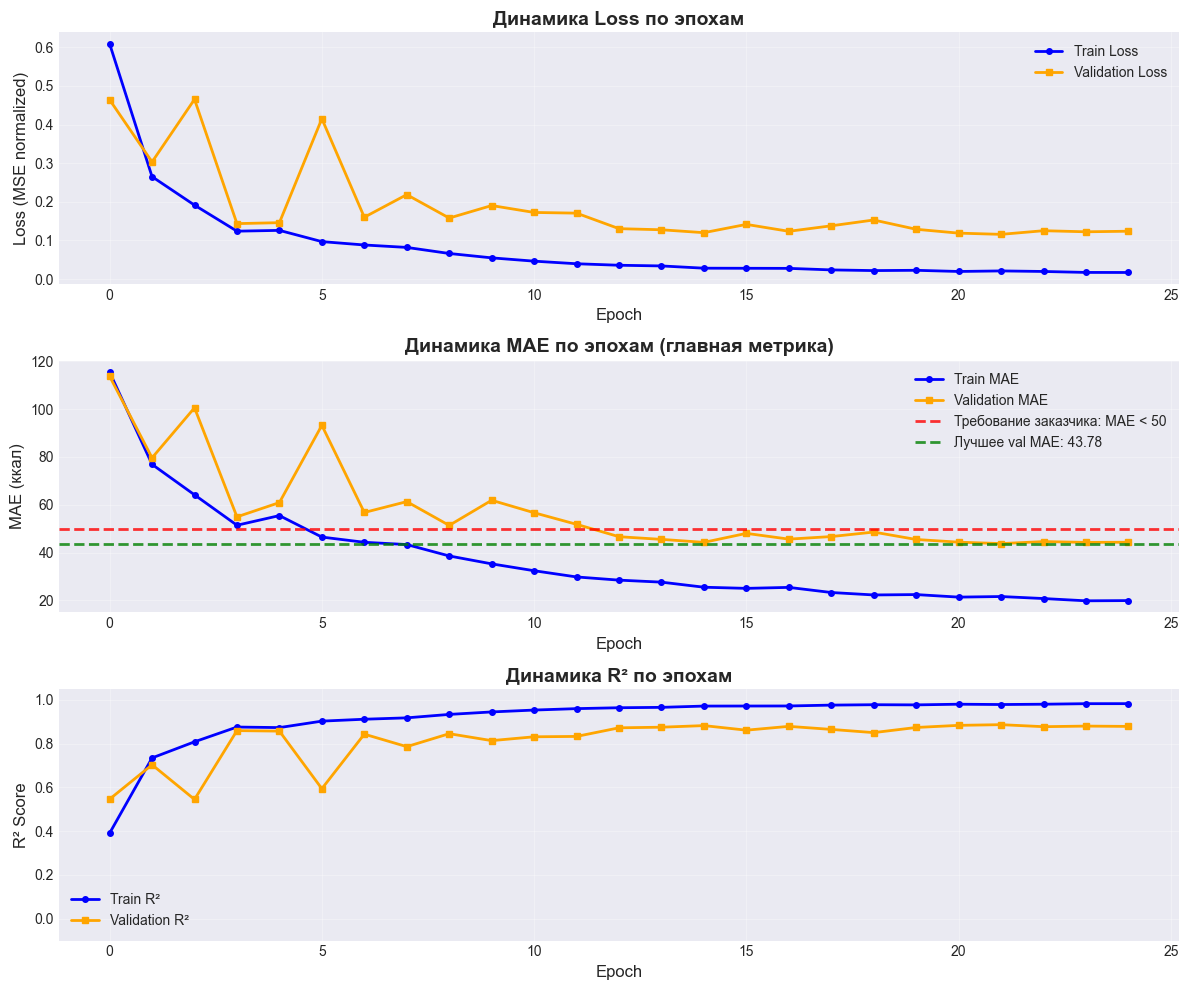


✅ ТРЕБОВАНИЕ ЗАКАЗЧИКА ВЫПОЛНЕНО!
   MAE = 43.78 < 50 ккал
💾 История обучения сохранена в: models\training_history.csv

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО! Все результаты сохранены в папке: models


In [14]:
# ============================================
# 11. ОСНОВНОЙ БЛОК ЗАПУСКА ОБУЧЕНИЯ
# ============================================

# Устанавливаем локальную папку для сохранения исходной "чистой" ResNet-50
current_dir = os.getcwd()
resnet50_dir = os.path.join(current_dir, "ResNet_50")
os.makedirs(resnet50_dir, exist_ok=True)
os.environ['TORCH_HOME'] = resnet50_dir
print(f"📁 Скаченная модель ResNet-50 будет сохранена в: {resnet50_dir}")
    
# Установка seed для воспроизводимости
set_seed(42)
    
# Создание папки для сохранения результатов
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
    
# Создание конфигурации
config = {
    'model_name': 'DishCalorieModel',
    'batch_size': 64,  
    'num_epochs': 25,  
    'learning_rate': 5e-4,  
    'weight_decay': 5e-5,  
    'dropout': 0.2,  
    'hidden_size': 1024,
    'num_ingredients': len(ingredients_df),
    'mixed_precision': True,
    'grad_clip': 1.0,
    'created_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}
    
# Сохраняем конфиг в JSON файл
config_path = save_dir / "config.json"
save_config(config, config_path)
    
# Загрузка конфига из файла
loaded_config = load_config(config_path)
    
print(f"\n📋 Загруженная конфигурация из файла:")
for key, value in loaded_config.items():
    print(f"   {key}: {value}")
    
# Создание Data Loader'ов
images_dir = os.path.join(DATASETS_DIR, 'images')
train_loader, val_loader, scaler, scaler_mass, scaler_target = get_data_loaders(
    dishes_df, images_dir, ingredients_df,
    batch_size=loaded_config['batch_size'],
    num_workers=0
)
    
# Сохранение scaler'ов для инференса
joblib.dump(scaler, save_dir / "ingredient_scaler.pkl")
joblib.dump(scaler_mass, save_dir / "mass_scaler.pkl")
joblib.dump(scaler_target, save_dir / "target_scaler.pkl")
print(f"💾 Scaler'ы сохранены в: {save_dir}")
    
# Создание модели 
model = DishCalorieModel(
    num_ingredients=loaded_config['num_ingredients'],
    hidden_size=loaded_config['hidden_size'],
    dropout=loaded_config['dropout']
).to(device)
    
# Подсчёт параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📊 Всего параметров: {total_params:,}")
print(f"📊 Обучаемых параметров: {trainable_params:,}")
    
# Настройка оптимизации 
criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=loaded_config['learning_rate'],
    weight_decay=loaded_config['weight_decay']
)
    
# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=loaded_config['num_epochs'],
    eta_min=1e-6
)
    
# Scaler для mixed precision
scaler_amp = GradScaler() if loaded_config['mixed_precision'] and device.type == 'cuda' else None
    
# Путь для сохранения модели
model_save_path = save_dir / "best_model.pth"
    
# Запуск обучения
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler_amp,
    device=device,
    config=config_path,
    model_save_path=model_save_path,
    scaler_target=scaler_target,
    grad_clip=loaded_config['grad_clip']
)
    
# ============================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ
# ============================================

# Создаём фигуру с 3 подграфиками
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# График Loss (MSE нормализованный)
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4, color='blue')
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2, markersize=4, color='orange')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE normalized)', fontsize=12)
axes[0].set_title('Динамика Loss по эпохам', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# График MAE (в ккал) — главная метрика
axes[1].plot(history['train_mae'], label='Train MAE', marker='o', linewidth=2, markersize=4, color='blue')
axes[1].plot(history['val_mae'], label='Validation MAE', marker='s', linewidth=2, markersize=4, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE (ккал)', fontsize=12)
axes[1].set_title('Динамика MAE по эпохам (главная метрика)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Добавляем горизонтальную линию — требование заказчика (MAE < 50) - цвет red
axes[1].axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label='Требование заказчика: MAE < 50')

# Добавляем горизонтальную линию — лучшее значение val MAE - цвет green
best_val_mae = min(history['val_mae'])
axes[1].axhline(y=best_val_mae, color='green', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Лучшее val MAE: {best_val_mae:.2f}')

# Обновляем легенду с новыми линиями
axes[1].legend(fontsize=10)

# 3. График R²
axes[2].plot(history['train_r2'], label='Train R²', marker='o', linewidth=2, markersize=4, color='blue')
axes[2].plot(history['val_r2'], label='Validation R²', marker='s', linewidth=2, markersize=4, color='orange')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('R² Score', fontsize=12)
axes[2].set_title('Динамика R² по эпохам', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([-0.1, 1.05])

plt.tight_layout()
plt.savefig(save_dir / "training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# Проверка выполнения требования заказчика
if best_val_mae < 50:
    print(f"\n✅ ТРЕБОВАНИЕ ЗАКАЗЧИКА ВЫПОЛНЕНО!")
    print(f"   MAE = {best_val_mae:.2f} < 50 ккал")
else:
    print(f"\n❌ ТРЕБОВАНИЕ ЗАКАЗЧИКА НЕ ВЫПОЛНЕНО")
    print(f"   MAE = {best_val_mae:.2f} >= 50 ккал")
    print(f"   Нужно увеличить количество эпох или настроить гиперпараметры")

print("="*60)

# Сохранение истории обучения
history_df = pd.DataFrame(history)
history_df.to_csv(save_dir / "training_history.csv", index=False)
print(f"💾 История обучения сохранена в: {save_dir / 'training_history.csv'}")
    
print(f"\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО! Все результаты сохранены в папке: {save_dir}")

Лучшая модель обладает MAE = 43,78 на 22-ой эпохе, что **удовлетворяет критерию заказчика** (MAE < 50 на тесте). Значение R2 на тесте составляет около 0,89, что тоже является неплохим показателем качества модели.

Посмотрим **топ-5 блюд, которые модель предсказывает хуже всего:**

Предсказание на валидации: 100%|██████████| 8/8 [00:06<00:00,  1.27it/s]



🔴 ТОП-5 БЛЮД С НАИБОЛЬШЕЙ ОШИБКОЙ (ОТ БОЛЬШЕЙ К МЕНЬШЕЙ)

1. dish_id: dish_1565811139
   📊 Истинная: 902 ккал
   🤖 Предсказанная: 450 ккал
   ❌ Ошибка: 452 ккал (50.1%)
   🍽️ Масса: 416.0 г
   📝 Состав (6 ингредиентов):
      - goat cheese
      - chicken
      - broccoli
      - carrot
      - spinach (raw)
      - olive oil

2. dish_id: dish_1558720236
   📊 Истинная: 888 ккал
   🤖 Предсказанная: 477 ккал
   ❌ Ошибка: 411 ккал (46.3%)
   🍽️ Масса: 407.0 г
   📝 Состав (4 ингредиентов):
      - apple
      - almonds
      - cauliflower
      - carrot

3. dish_id: dish_1558375886
   📊 Истинная: 1051 ккал
   🤖 Предсказанная: 744 ккал
   ❌ Ошибка: 306 ккал (29.2%)
   🍽️ Масса: 277.0 г
   📝 Состав (3 ингредиентов):
      - sausage
      - grapes
      - almonds

4. dish_id: dish_1558549806
   📊 Истинная: 782 ккал
   🤖 Предсказанная: 499 ккал
   ❌ Ошибка: 283 ккал (36.2%)
   🍽️ Масса: 203.0 г
   📝 Состав (3 ингредиентов):
      - almonds
      - white rice
      - spinach (raw)

5. dish_id:

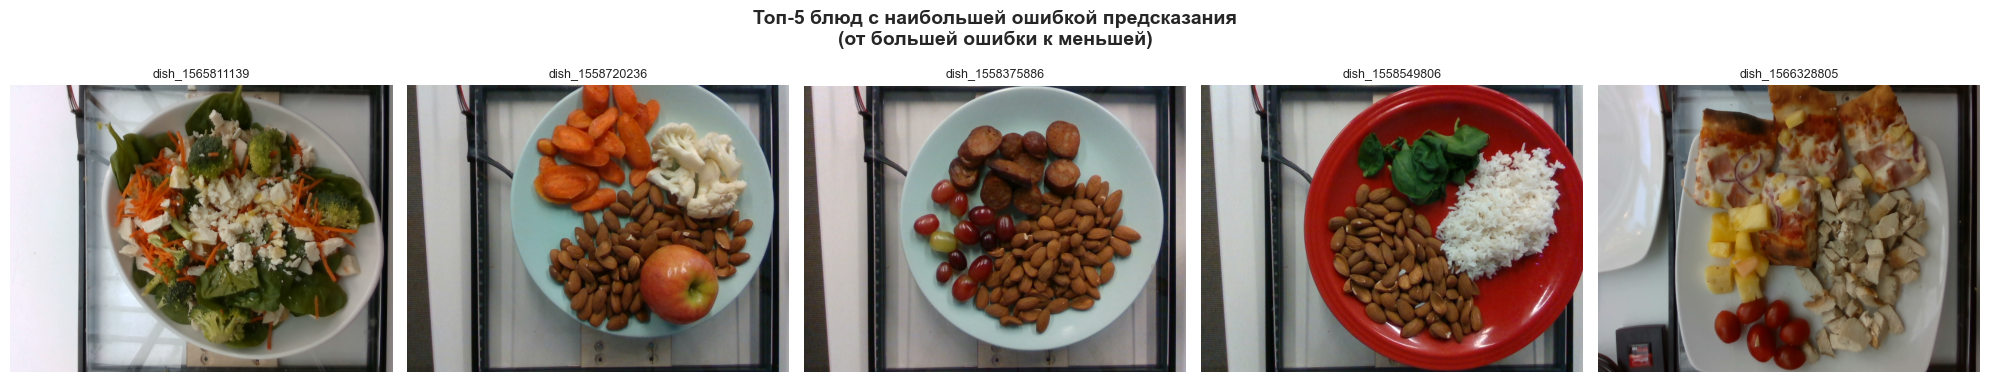


🔍 АНАЛИЗ РЕДКИХ ИНГРЕДИЕНТОВ В ТОП-5 ОШИБКАХ

📊 Редкие ингредиенты в топ-5 блюдах (встречаются в <5% всех блюд):
   - goat cheese: частота 0.71%
   - pizza: частота 2.64%
   - sausage: частота 2.92%
   - grapes: частота 3.87%


In [15]:
# ============================================
# 12. ТОП-5 БЛЮД С НАИБОЛЬШЕЙ ОШИБКОЙ 
# ============================================

# Получаем предсказания модели на валидационной выборке
model.eval()
predictions_list = []
targets_list = []
dish_ids_list = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Предсказание на валидации"):
        images = batch['image'].to(device)
        ingredients = batch['ingredients'].to(device)
        mass = batch['mass'].to(device)
        
        outputs = model(images, ingredients, mass)
        
        predictions_list.extend(outputs.cpu().numpy())
        targets_list.extend(batch['calories'].cpu().numpy())
        dish_ids_list.extend(batch['dish_id'])

# Обратное преобразование в исходные калории
predictions = scaler_target.inverse_transform(np.array(predictions_list).reshape(-1, 1)).flatten()
targets = scaler_target.inverse_transform(np.array(targets_list).reshape(-1, 1)).flatten()

# Создаём DataFrame с результатами
results_df = pd.DataFrame({
    'dish_id': dish_ids_list,
    'true_calories': targets,
    'predicted_calories': predictions,
    'absolute_error': np.abs(targets - predictions),
    'relative_error': np.abs(targets - predictions) / targets * 100
})

# Сортируем по абсолютной ошибке (от наибольшей к наименьшей)
results_sorted = results_df.sort_values('absolute_error', ascending=False).reset_index(drop=True)

# Берём первые 5
top5 = results_sorted.head(5).copy()

# Создаём словарь с числовыми ключами для совместимости с id_to_ingredient_name
# ingr_dict из ingredients_df имеет ключи-числа (int)
ingr_dict_numeric = ingr_dict  # уже int ключи

# Функция для получения названия ингредиента через универсальную функцию
def get_ingredient_name(ingr_str):
    """Обёртка над id_to_ingredient_name для совместимости со старым кодом"""
    return id_to_ingredient_name(ingr_str, ingr_dict_numeric, default_prefix="unknown")

# Расчёт частоты встречаемости ингредиентов 
all_ingredients_flat = []
for ingredients_list in dishes_df['ingredients_list']:
    all_ingredients_flat.extend(ingredients_list)

ingredient_freq = Counter(all_ingredients_flat)
total_dishes = len(dishes_df)

# Вывод топ-5 "худших" блюд 
print("\n" + "="*80)
print("🔴 ТОП-5 БЛЮД С НАИБОЛЬШЕЙ ОШИБКОЙ (ОТ БОЛЬШЕЙ К МЕНЬШЕЙ)")
print("="*80)

# Итерируемся по top5 в том порядке, который задан сортировкой
for idx, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"\n{idx}. dish_id: {row['dish_id']}")
    print(f"   📊 Истинная: {row['true_calories']:.0f} ккал")
    print(f"   🤖 Предсказанная: {row['predicted_calories']:.0f} ккал")
    print(f"   ❌ Ошибка: {row['absolute_error']:.0f} ккал ({row['relative_error']:.1f}%)")
    
    dish_info = dishes_df[dishes_df['dish_id'] == row['dish_id']]
    if len(dish_info) > 0:
        dish_row = dish_info.iloc[0]
        print(f"   🍽️ Масса: {dish_row['total_mass']} г")
        
        ingredients_list = dish_row['ingredients_list']
        print(f"   📝 Состав ({len(ingredients_list)} ингредиентов):")
        
        ingredients_with_info = []
        for ingr_name in ingredients_list:  
            # ingr_name уже является названием, не нужно преобразовывать
            freq = ingredient_freq.get(ingr_name, 0)
            freq_percent = freq / total_dishes * 100
            ingredients_with_info.append((ingr_name, freq, freq_percent))
        
        ingredients_with_info.sort(key=lambda x: x[1])
        
        for ingr_name, freq, freq_percent in ingredients_with_info[:15]:
            if len(ingr_name) > 30:
                ingr_name = ingr_name[:27] + "..."
            print(f"      - {ingr_name}")
        
        if len(ingredients_with_info) > 30:
            print(f"      ... и еще {len(ingredients_with_info) - 15} ингредиентов")

# Фотографии топ-5 блюд 
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (_, row) in enumerate(top5.iterrows()):
    dish_id = row['dish_id']
    img_path = os.path.join(DATASETS_DIR, 'images', dish_id, 'rgb.png')
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[idx].imshow(img)
    else:
        axes[idx].text(0.5, 0.5, 'Нет фото', ha='center', va='center', fontsize=12)
    
    axes[idx].set_title(f"{dish_id}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Топ-5 блюд с наибольшей ошибкой предсказания\n(от большей ошибки к меньшей)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Анализ редких ингредиентов в топ-5 "худших" блюдах
print("\n" + "="*80)
print("🔍 АНАЛИЗ РЕДКИХ ИНГРЕДИЕНТОВ В ТОП-5 ОШИБКАХ")
print("="*80)

top5_ingredients = []
for _, row in top5.iterrows():
    dish_info = dishes_df[dishes_df['dish_id'] == row['dish_id']]
    if len(dish_info) > 0:
        top5_ingredients.extend(dish_info.iloc[0]['ingredients_list'])

top5_ingr_freq = Counter(top5_ingredients)

print("\n📊 Редкие ингредиенты в топ-5 блюдах (встречаются в <5% всех блюд):")
rare_in_top5 = []

for ingr_name, count_in_top5 in top5_ingr_freq.items():
    freq_total = ingredient_freq.get(ingr_name, 0)
    freq_percent = freq_total / total_dishes * 100
    if freq_percent < 5.0:
        rare_in_top5.append((ingr_name, freq_percent, count_in_top5))

rare_in_top5.sort(key=lambda x: x[1])

for ingr_name, freq_percent, count_in_top5 in rare_in_top5[:15]:
    if len(ingr_name) > 35:
        ingr_name = ingr_name[:32] + "..."
    print(f"   - {ingr_name}: частота {freq_percent:.2f}%")

if len(rare_in_top5) == 0:
    print("   ✅ В топ-5 блюдах нет редких ингредиентов")

**Плохие предсказания** калорийности этих блюд (ошибка 28-50 % или 250-450 ккал) можно объяснить **следующими причинами:**

— с точки зрения калорийности эти блюда — **редкие** экземпляры, поскольку их калорийность лежит в диапазоне 800-1000 ккал, а подавляющее большинство блюд имеет калорийность до 700 ккал (согласно разделу 2.1), поэтому модель на них сильно ошибается; при этом по весу (200-500 г) эти блюда укладываются в "стандартные" значения (0-500 г)

— в состав этих блюд входят **редкие ингредиенты** (встречаются менее чем в 5 % блюд), то есть у модели мало примеров блюд с такими ингредиентами и ей сложно сделать обобщение для таких блюд

— на фотографиях эти блюда выглядят довольно **неоднородно**, присутствуют **много** ингредиентов **разных цветов и очертаний** (при этом, например, в датасете есть блюда всего из одного компонента и выглядят они "просто") — такие фото тяжело "воспринимаются" моделью

Для улучшения предсказаний на таких блюдах можно порекомендовать увеличить количество похожих блюд в исходных данных (если такая возможность есть).

**ВЫВОДЫ ПО РАЗДЕЛУ 3:**

**Проведено обучение и разработана лучшая мультимодальная модель с архитектурой, предложенной в разделе 2:**

— на 22-ой эпохе  **достигнуто MAE = 43,78** на тестовой выборке, **что удовлетворяет критерию заказчика (MAE < 50 на тесте)**

— MSE и R2 лучшей модели на тестовой выборке (22-я эпоха) составляют 0,1157 и 0,8870 соответственно

— лучшая модель и её конфиг **сохранены в папке models**

— некоторые блюда модель предсказывает **плохо** (топ-5 "наихудших"), что **можно быть связано** с их необычайно высокой калорийностью (редкие экземпляры), содержание редких ингредиентов (мало примеров с такими ингредиентами) и слишком "пёстрыми" фотографиями (много компонентов разной формы и цветов) — из-за этих факторов модели сложно делать обобщения для таких блюд 

## **4. Итоговые выводы**

В ходе проведённой работы **проведён анализ и предобработка** исходных данных (анализ распределения признаков, удаление аномальных значений и фото без численных параметров и другие). В результате  **разработана модель,** способная предсказывать калорийность блюд по табличным данным (масса, состав) и по фото с MAE = 43,78 на тестовой выборке, что **удовлетворяет требованию заказчика** (MAE < 50 на тестовой выборке). Значение R2 лучшей модели на тестовой выборке составляет порядка 0,89, что дополнительно свидетельствует о хорошем качестве модели. Данная модель является **мультимодальной моделью**, состоящей из предпобученной модели ResNet-50, отвечающей за работу с фотографиями (модель была дообучена на наших данных), и двух обученных "с нуля" многослойных перцептронов (MLP) для работы с массой и составом (ингредиентами). Для повышения точности модели использовали агументции фото (повороты, отражения, вариации констрастности) и one-hot представление ингредиентов, то есть векторное представление состава каждого блюда. 

Калорийность некоторых блюд модель предсказывает **плохо**, что, по-видимому, **связано с** их необычайно редкой высокой калорийностью (редкие экземпляры), содержанием редких ингредиентов (затрудняет обобщение) и неоднородностью (наличие разнообразных компонентов) фотографий этих блюд.

**Точность модели можно улучшить за счёт:**
- увеличения количества эпох (сейчас их 25), скажем, до 40 или 60 - хотя при прочих равных улучшение будет незначительным, поскольку значение MAE для валидации вышло на плато уже к 20-ой эпохе
- другого планировщика скорости обучения (learning rate scheduler), например, попробовать StepLR или ReduceLROnPlateau, а не CosineAnnealingLR
- возможно, более расширенных настроек аугментация данных (например, сделать повороты на большее число градусов), но **не уверен**, что в данном случае это улучшит модель
- разморозка большего числа слоёв и, соответственно, дообучение большего числа слоёв в ResNet-50, отвечающей за работу с изображениями
- выбора другой нейросети для работы с изображениями (например, ResNet-101 или ResNet-152)

**Отметим,** что разработанная модель, помимо хорошего MAE (< 50), довольно быстро обучается на текущих данных (около 30 минут, то есть ~ 1 мин на эпоху), поэтому при наличии большего объёма новых данных нашу модель можно сравнительно быстро переобучить.